# Objectives

In this notebook, the results of CKF stress test using KITTI dataset is agregated and the agregated results are exported.
The noise stress test is conducted on CKF with variable noise factor in range 0.1, 1.0, and 10.0 for sensor modality including OXTS IMU, OXTS GPS and Visual Odometry. Hence, there are 27 combinations of sensor configuration

The data agregation includes:
- 2D heat map per sensor axis (e.g., 3x3 heatmap for each IMU configuration: 0.1, 1.0, 10.0). Each cell presents ATE.
- Sensitivity for each sensor given by: sensitivity = (ATE_{a=10.0} - ATE_{a=0.1}) / ATE_{a=1.0}

to reveal which modality is most senstitive.

This is an updated version of noise stress test, where GPS and VO noise in cofiguration file is changed to the values used in other experiments presented in the paper. 

In [16]:
import os
import re
import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from typing import List
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from collections import namedtuple
from IPython.core.display import display, HTML
from IPython.display import Image

warnings.filterwarnings("ignore")

In [17]:
# folder_name = "outputs/KITTI/noise_stress_test/results_2026-02-18-22-46-25"
folder_name = "outputs/KITTI/noise_stress_test/results_2026-04-17-16-03-52"

In [18]:
result_csv_filename = f'{folder_name}/noise_stress_test_results_seq_07.csv'
results_df = pd.read_csv(result_csv_filename)

In [19]:
static_noise_df_filter = results_df['is_adaptive_noise_management'] == False
adaptive_noise_df_filter = results_df['is_adaptive_noise_management'] == True

results_df

,sequence,filter_type,motion_model,sensor,vo_estimation_type,mae,ate,rpe_m,rpe_deg,avg_inference_time_prediction_step,avg_inference_time_correction_step,imu_noise_scale,vo_noise_scale,gps_noise_scale,is_adaptive_noise_management
0,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,1.708129,4.123754,0.032851,0.090743,0.000784,0.000304,0.1,0.1,0.1,False
1,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.686649,9.009488,0.056916,0.091606,0.000771,0.000289,0.1,0.1,1.0,False
2,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,5.463734,13.477088,0.078929,0.092141,0.000769,0.000280,0.1,0.1,10.0,False
3,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,0.759902,1.807869,0.025592,0.056799,0.000772,0.000285,0.1,1.0,0.1,False
4,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,1.299327,3.095447,0.030908,0.057764,0.000769,0.000284,0.1,1.0,1.0,False
5,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.670464,9.007545,0.058560,0.059128,0.000773,0.000289,0.1,1.0,10.0,False
6,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,0.700620,1.662450,0.030476,0.046303,0.000774,0.000294,0.1,10.0,0.1,False
7,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,0.757810,1.774084,0.031054,0.046574,0.000770,0.000284,0.1,10.0,1.0,False
8,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,1.312800,3.039800,0.037132,0.047060,0.000771,0.000282,0.1,10.0,10.0,False
9,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,2.892786,7.049569,0.046366,0.086443,0.000776,0.000291,1.0,0.1,0.1,False


In [20]:
static_noise_df = results_df[static_noise_df_filter]

imu_0_1_df = static_noise_df[static_noise_df['imu_noise_scale'] == 0.1]
imu_1_df = static_noise_df[static_noise_df['imu_noise_scale'] == 1.0]
imu_10_df = static_noise_df[static_noise_df['imu_noise_scale'] == 10.0]

In [21]:
imu_0_1_df

,sequence,filter_type,motion_model,sensor,vo_estimation_type,mae,ate,rpe_m,rpe_deg,avg_inference_time_prediction_step,avg_inference_time_correction_step,imu_noise_scale,vo_noise_scale,gps_noise_scale,is_adaptive_noise_management
0,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,1.708129,4.123754,0.032851,0.090743,0.000784,0.000304,0.1,0.1,0.1,False
1,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.686649,9.009488,0.056916,0.091606,0.000771,0.000289,0.1,0.1,1.0,False
2,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,5.463734,13.477088,0.078929,0.092141,0.000769,0.000280,0.1,0.1,10.0,False
3,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,0.759902,1.807869,0.025592,0.056799,0.000772,0.000285,0.1,1.0,0.1,False
4,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,1.299327,3.095447,0.030908,0.057764,0.000769,0.000284,0.1,1.0,1.0,False
5,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.670464,9.007545,0.058560,0.059128,0.000773,0.000289,0.1,1.0,10.0,False
6,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,0.700620,1.662450,0.030476,0.046303,0.000774,0.000294,0.1,10.0,0.1,False
7,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,0.757810,1.774084,0.031054,0.046574,0.000770,0.000284,0.1,10.0,1.0,False
8,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,1.312800,3.039800,0.037132,0.047060,0.000771,0.000282,0.1,10.0,10.0,False


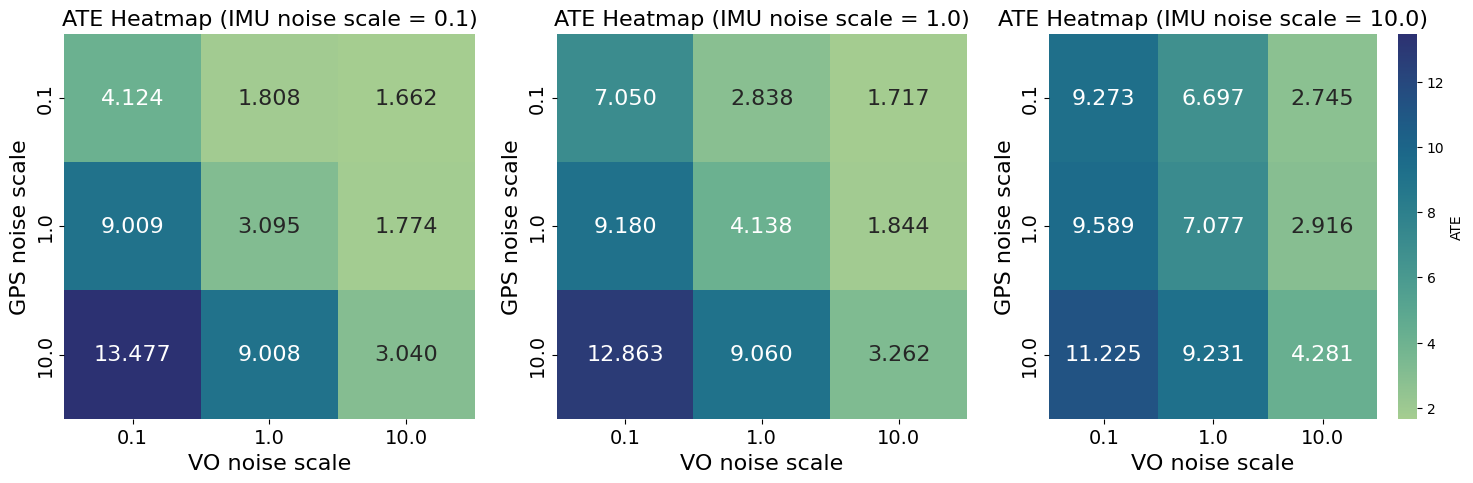

In [22]:
ate_matrix_imu_0_1 = imu_0_1_df.pivot(
    index="gps_noise_scale",
    columns="vo_noise_scale",
    values="ate"
).sort_index().sort_index(axis=1)

ate_matrix_imu_1 = imu_1_df.pivot(
    index="gps_noise_scale",
    columns="vo_noise_scale",
    values="ate"
).sort_index().sort_index(axis=1)

ate_matrix_imu_10 = imu_10_df.pivot(
    index="gps_noise_scale",
    columns="vo_noise_scale",
    values="ate"
).sort_index().sort_index(axis=1)

vmin = min(ate_matrix_imu_0_1.values.min(), ate_matrix_imu_1.values.min(), ate_matrix_imu_10.values.min())
vmax = max(ate_matrix_imu_0_1.values.max(), ate_matrix_imu_1.values.max(), ate_matrix_imu_10.values.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

heatmap_data = [
    (ate_matrix_imu_0_1, "ATE Heatmap (IMU noise scale = 0.1)"),
    (ate_matrix_imu_1,   "ATE Heatmap (IMU noise scale = 1.0)"),
    (ate_matrix_imu_10,  "ATE Heatmap (IMU noise scale = 10.0)"),
]

for i, (ax, (matrix, title)) in enumerate(zip(axes, heatmap_data)):
    is_last = i == len(heatmap_data) - 1
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="crest",
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        cbar=is_last,
        cbar_kws={"label": "ATE"} if is_last else {}
    )
    ax.set_title(title)
    ax.set_xlabel("VO noise scale", fontsize=16)
    ax.set_ylabel("GPS noise scale", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_title(title, fontsize=16)
    for text in ax.texts:
        text.set_fontsize(16)

fig_filename = f'{folder_name}/ate_heatmaps.png'
fig.savefig(fig_filename, bbox_inches='tight', dpi=150)
plt.show()

In [23]:
imu_noise_scale = static_noise_df.pivot(
    index="imu_noise_scale",
    columns=["gps_noise_scale", "vo_noise_scale"],
    values="ate"
).sort_index().sort_index(axis=1)
imu_0_1_mean = imu_noise_scale.iloc[0].mean()
imu_1_mean = imu_noise_scale.iloc[1].mean()
imu_10_mean = imu_noise_scale.iloc[2].mean()
sensitivity_imu = (imu_10_mean - imu_0_1_mean) / imu_1_mean

gps_noise_scale = static_noise_df.pivot(
    index="gps_noise_scale",
    columns=["imu_noise_scale", "vo_noise_scale"],
    values="ate"
).sort_index().sort_index(axis=1)
gps_0_1_mean = gps_noise_scale.iloc[0].mean()
gps_1_mean = gps_noise_scale.iloc[1].mean()
gps_10_mean = gps_noise_scale.iloc[2].mean()
sensitivity_gps = (gps_10_mean - gps_0_1_mean) / gps_1_mean

vo_noise_scale = static_noise_df.pivot(
    index="vo_noise_scale",
    columns=["imu_noise_scale", "gps_noise_scale"],
    values="ate"
).sort_index().sort_index(axis=1)
vo_0_1_mean = vo_noise_scale.iloc[0].mean()
vo_1_mean = vo_noise_scale.iloc[1].mean()
vo_10_mean = vo_noise_scale.iloc[2].mean()
sensitivity_vo = (vo_10_mean - vo_0_1_mean) / vo_1_mean

print(f"IMU sensitivity: {sensitivity_imu:.4f}")
print(f"GPS sensitivity: {sensitivity_gps:.4f}")
print(f"VO sensitivity:  {sensitivity_vo:.4f}")

IMU sensitivity: 0.3087
GPS sensitivity: 0.7719
VO sensitivity:  -1.1812


## Analysis

The three heatmaps depict Absolute Trajectory Error for each noise scale value for GPS and Visual Odometry when IMU noise scale is set to 0.1, 1.0, and 10.0 respectively.

First of all, throughout the noise stress test, CKF has never presented filter divergence showcasing the filter's robustness on different noise environment.

The result reveals that in this multi modal fusion configuration, IMU and GPS noise scale has a crucial role such that there is a correlation between noise scale of both IMU and GPS sensor and the CKF's localization performance.
Not to mention the GPS noise impact on the performance of the CKF, the selection of IMU noise scale has a noiticable impact on the fusion performance as the ATE value increases when increase in IMU noise value, although measurement noise for both VO and GPS is kept small. The sensitivity analysis on both sensor provides positive values, which justifies the aformentioned analysis numerically.

In contrast, the scale of visual odometry noise has a negative impact on the fitler performance as it is observed that incrase in the visual odometry noise scale decreases the filter performance, as the sensitivity of VO presents negative value. This is because of the filter balancing between the GPS and VO, as positioning accuracy of GPS is much accurate than the VO, the filter relies on GPS data when VO noise scale increases resulting in aqcuiring hgih accuracy in localziation.

This experiment provides an insight on the robstness and potential of the CKF by presenting the capability of balancing between selected sensor modality based on the noise characteristic of each sensor. Moreover, it offers a possibility of integrating context-aware knowledge-based noise management localization under dynamic environment.

## Refined version

The three heatmaps in Figure~\ref{fig:noise_stress_test} illustrate the ATE across different combinations of GPS and VO noise scaling factors, with the IMU noise scale fixed at 0.1, 1.0, and 10.0, respectively. The computed sensitivity values are 0.3087 for IMU, 0.7719 for GPS, and −1.1812-1.1812
−1.1812 for VO.

Throughout the 27 noise configurations, the CKF did not exhibit filter divergence or covariance instability in any case, confirming the numerical robustness of the filter under substantial noise mis-specification.
The results reveal that, within this multi-modal fusion configuration, both IMU and GPS noise scaling exert a significant influence on localization performance. The positive sensitivity values for IMU (0.3087) and GPS (0.7719) indicate that increasing the assumed noise level leads to a proportional increase in trajectory error. Notably, even when the measurement noise for both VO and GPS is kept small, the selection of IMU process noise scale has a considerable impact on fusion accuracy, as reflected in the rising ATE values with increasing IMU noise. Among the two, GPS exhibits the higher sensitivity, suggesting that the localization performance in this configuration is most influenced by the assumed GPS measurement noise.
In contrast, the VO sensitivity is negative (−1.1812-1.1812
−1.1812), implying that increasing the assumed VO noise scale improves overall localization accuracy. This behavior is attributable to the filter's adaptive weighting mechanism: as VO noise increases, the CKF reduces the weight assigned to potentially drift-prone visual estimates and relies more heavily on GPS, which provides globally referenced position measurements with comparatively higher accuracy in the selected KITTI sequence. This does not imply that VO is detrimental to the fusion; rather, it reflects dataset-dependent characteristics wherein GPS quality is consistently high. In scenarios where GPS degrades, such as urban canyons or multipath conditions, the sensitivity behavior is expected to differ.

Overall, this experiment demonstrates two key properties of the pipeline: the CKF maintains numerical stability and bounded error across large variations in assumed noise levels, and the fusion mechanism appropriately re-balances sensor contributions according to their modeled uncertainty. These findings support future integration of context-aware, knowledge-based adaptive noise management strategies for localization under dynamic environments.